In [41]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import random
import pathlib
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models,Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2,ResNet50
from tensorflow.keras.callbacks import EarlyStopping


import zipfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import shutil

SEED_VALUE = 801
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

### Extract the file using zipfile library

In [42]:
fileRead = zipfile.ZipFile('2A.zip', 'r')
fileRead.extractall('Dataset2A')
fileRead.close()

In [43]:
print(os.listdir('Dataset2A'))

['2D']


## **Checking Class Distribution**

In [44]:
dataPath = pathlib.Path('Dataset2A/2D/data')

In [45]:
def performEda(path):
    imageStats = []
    categories = sorted([f.name for f in path.iterdir() if f.is_dir()])

    for category in categories:
        folderPath = path / category
        files = list(folderPath.glob('*'))
        print(f"{category}: {len(files)} images")

        # ambil sampel 10 gambar untuk cek resolusi
        samples = files[:10]
        for s in samples:
            if s.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                with Image.open(s) as img:
                    w, h = img.size
                    imageStats.append({
                        'category': category,
                        'width': w,
                        'height': h,
                        'aspectRatio': w/h
                    })

    return pd.DataFrame(imageStats)

In [46]:
dfEda = performEda(dataPath)
print("\nStatistics for resolution & aspect ratio")
print(dfEda.describe())

Blight: 1146 images
Common_Rust: 1306 images
Gray_Leaf_Spot: 574 images
Healthy: 1162 images

Statistics for resolution & aspect ratio
             width       height  aspectRatio
count    40.000000    40.000000    40.000000
mean    328.225000   309.725000     1.042373
std     227.135054   192.587508     0.161544
min     256.000000   256.000000     0.750000
25%     256.000000   256.000000     1.000000
50%     256.000000   256.000000     1.000000
75%     256.000000   256.000000     1.000000
max    1333.000000  1200.000000     1.709402


In [47]:
baseSplitDir = "split_data"
trainDir = os.path.join(baseSplitDir, "train")
valDir = os.path.join(baseSplitDir, "val")
testDir = os.path.join(baseSplitDir, "test")

classNames = sorted(os.listdir(trainDir))
print("classes found:", classNames)

def countImages(directory, splitName):
    print(f"\nAmount per class in {splitName}")
    total = 0
    for className in classNames:
        classPath = os.path.join(directory, className)
        numImages = len(os.listdir(classPath))
        print(f"{className}: {numImages} images")
        total += numImages
    print(f"total {splitName}: {total} images")

countImages(trainDir, "Train")
countImages(valDir, "Validation")
countImages(testDir, "Test")

classes found: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

Amount per class in Train
Blight: 802 images
Common_Rust: 914 images
Gray_Leaf_Spot: 401 images
Healthy: 813 images
total Train: 2930 images

Amount per class in Validation
Blight: 172 images
Common_Rust: 196 images
Gray_Leaf_Spot: 86 images
Healthy: 174 images
total Validation: 628 images

Amount per class in Test
Blight: 172 images
Common_Rust: 196 images
Gray_Leaf_Spot: 87 images
Healthy: 175 images
total Test: 630 images


## **Sample Image per Class**

image shape: (256, 256, 3)
image shape: (256, 256, 3)
image shape: (256, 256, 3)
image shape: (256, 256, 3)


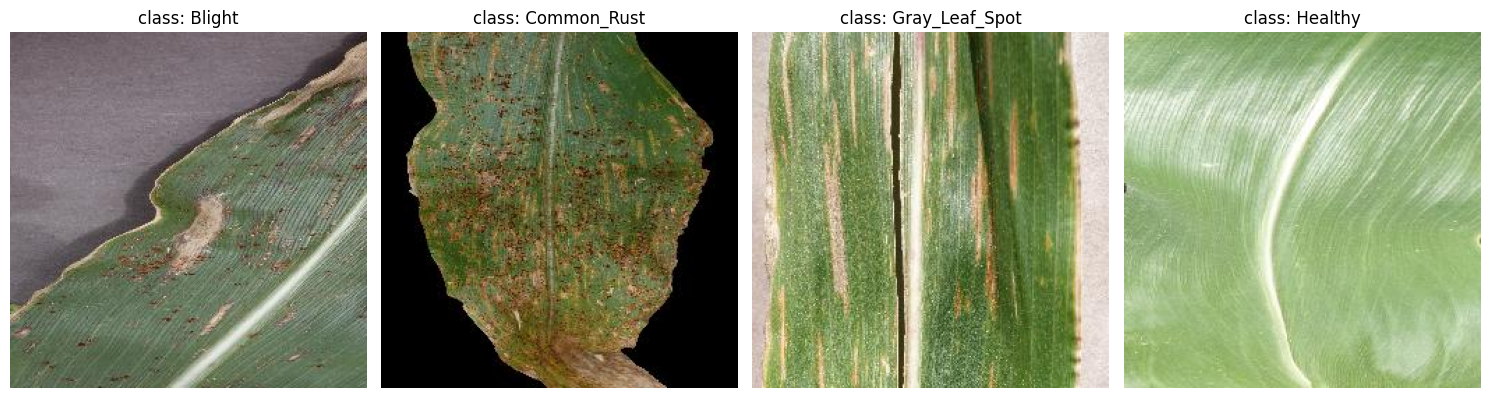

In [54]:
def viewRandomImage(targetPath, targetClass):
    # pastikan nama variabel di sini 'targetClass'
    targetFolder = os.path.join(targetPath, targetClass)

    imageFilename = random.choice(os.listdir(targetFolder))
    imagePath = os.path.join(targetFolder, imageFilename)

    image = mpimg.imread(imagePath)
    plt.imshow(image)
    plt.title(f"class: {targetClass}")
    plt.axis("off")

    print(f"image shape: {image.shape}")
    return image

trainDirPath = "split_data/train"
classList = sorted(os.listdir(trainDirPath))

plt.figure(figsize=(15, 10))
for i, className in enumerate(classList):
    plt.subplot(1, 4, i+1)
    # di sini ganti 'target_class' jadi 'targetClass' biar sama kayak di atas
    viewRandomImage(targetPath=trainDirPath, targetClass=className)

plt.tight_layout()
plt.show()

## **Simple EDA**

### **Checking Image Dimensions**


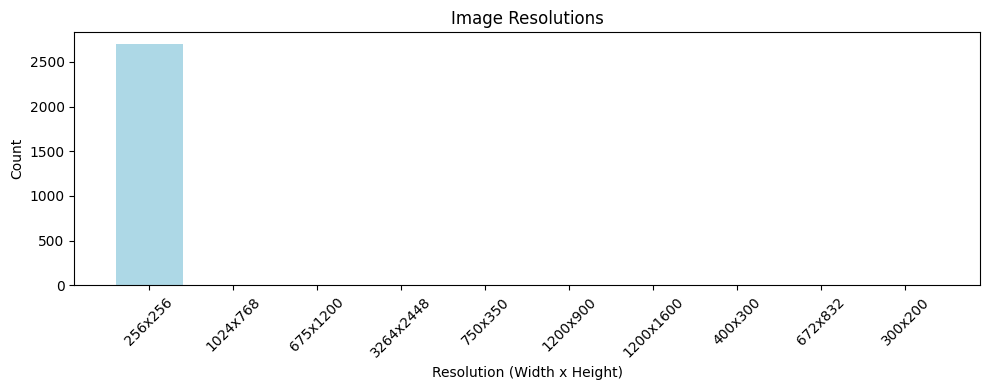


Mean Aspect Ratio: 1.02
Unique Resolutions found: 182


In [52]:
def check_image_shapes(folder):
    ratios = []
    sizes = []

    for class_folder in os.listdir(folder):
        path = os.path.join(folder, class_folder)
        if not os.path.isdir(path): continue

        for img_file in os.listdir(path):
            if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(path, img_file)
                try:
                    img = Image.open(img_path)
                    w, h = img.size
                    ratios.append(w / h)
                    sizes.append((w, h))
                except:
                    continue

    return ratios, sizes

ratios, sizes = check_image_shapes("split_data/train")

res_counts = {}
for res in sizes:
    res_counts[res] = res_counts.get(res, 0) + 1

top_res = sorted(res_counts.items(), key=lambda x: x[1], reverse=True)[:10]
labels, counts = zip(*top_res)

plt.figure(figsize=(10, 4))
plt.bar([f"{w}x{h}" for (w, h) in labels], counts, color='lightblue')
plt.title("Image Resolutions")
plt.xlabel("Resolution (Width x Height)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMean Aspect Ratio: {np.mean(ratios):.2f}")
print(f"Unique Resolutions found: {len(res_counts)}")

Based on the histogram above all out images files are already in a 256x256 dimension meaning that all of it is in a 1:1 aspect ratio, already in the right size to use with AlexNet

### **Color Variability Check**

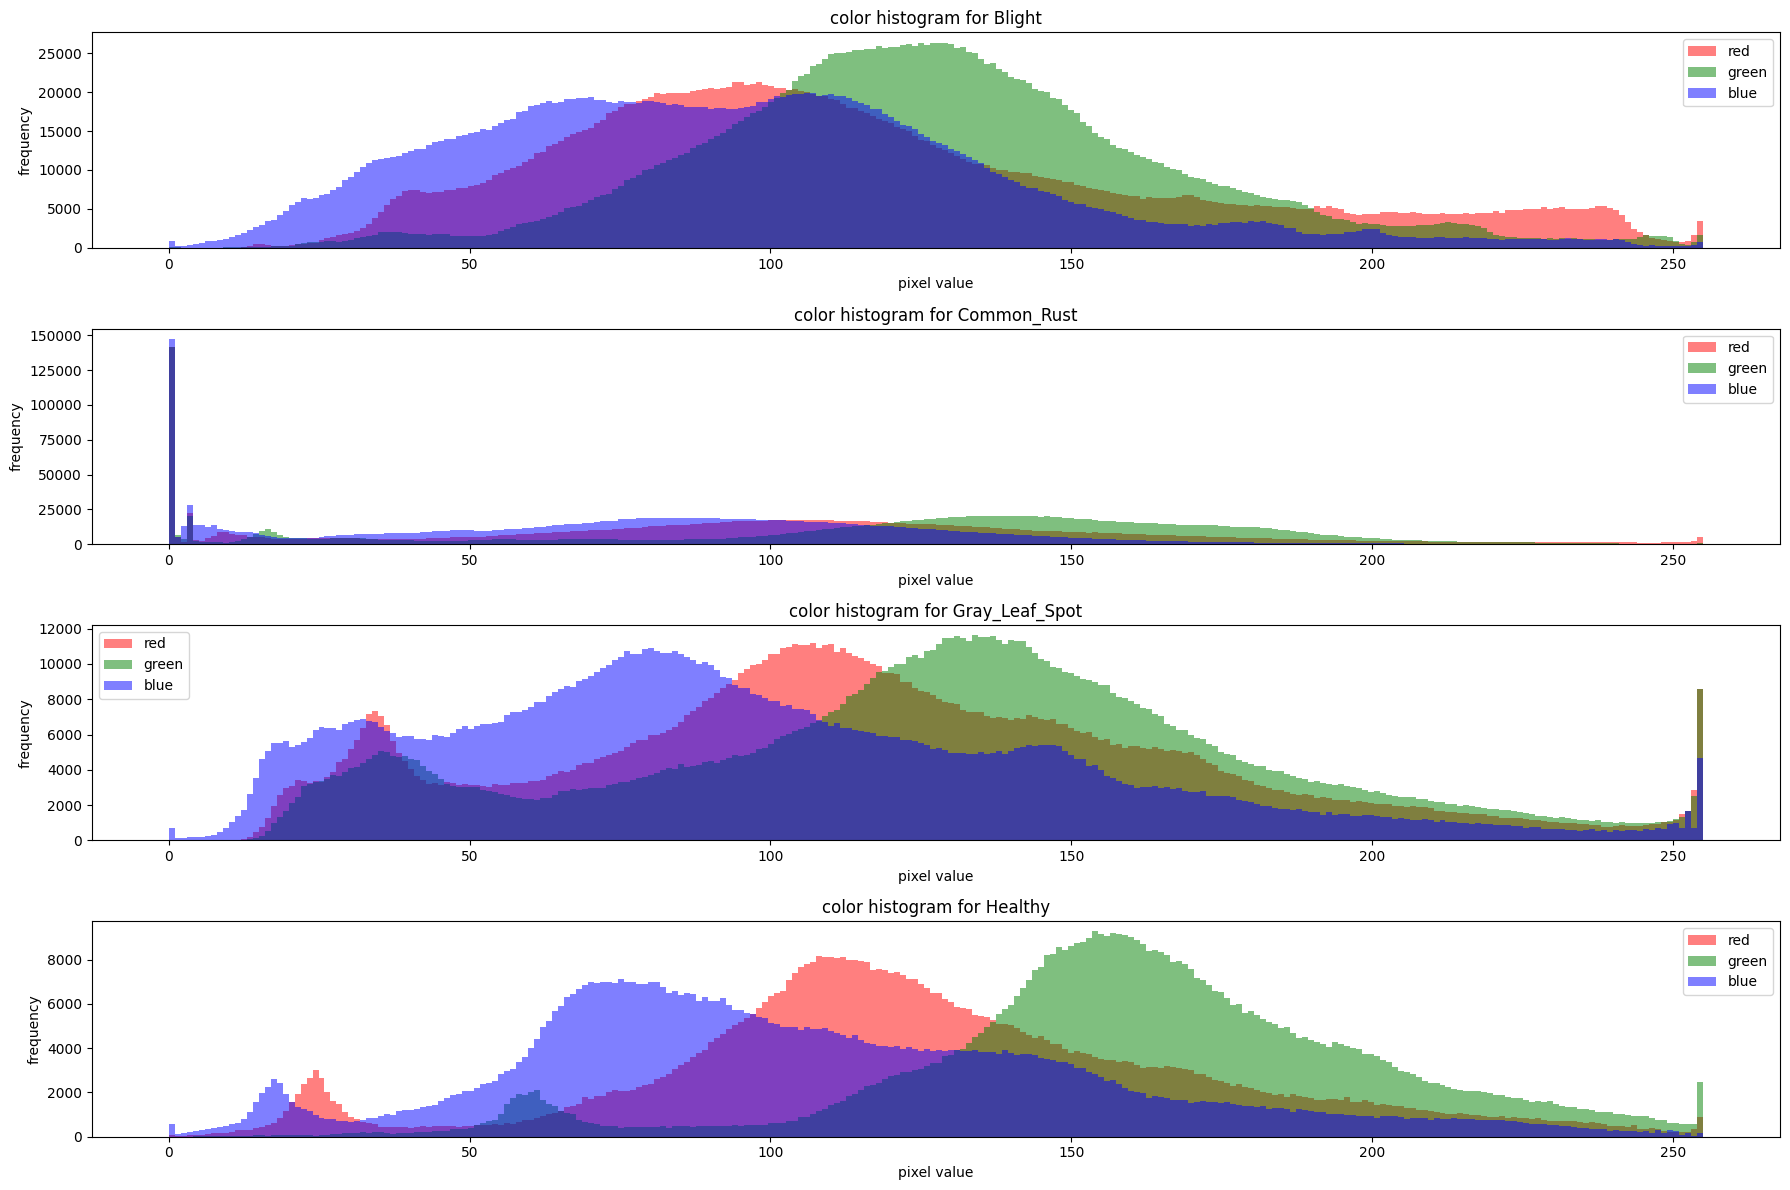

In [53]:
def computeColorHistogram(folder, maxImages=10):
    rVals, gVals, bVals = [], [], []

    count = 0
    for imgName in os.listdir(folder):
        if imgName.lower().endswith(('jpg', 'jpeg', 'png')):
            imgPath = os.path.join(folder, imgName)
            try:
                img = Image.open(imgPath).convert('RGB')
                r, g, b = img.split()
                rVals.extend(np.array(r).flatten())
                gVals.extend(np.array(g).flatten())
                bVals.extend(np.array(b).flatten())
                count += 1
                if count >= maxImages:
                    break
            except:
                continue

    return rVals, gVals, bVals

def plotColorHistogramsByClass(baseDir, maxImagesPerClass=10):
    classDirs = sorted([d for d in os.listdir(baseDir) if os.path.isdir(os.path.join(baseDir, d))])

    plt.figure(figsize=(18, 12))

    for i, className in enumerate(classDirs):
        folder = os.path.join(baseDir, className)
        r, g, b = computeColorHistogram(folder, maxImages=maxImagesPerClass)

        plt.subplot(len(classDirs), 1, i + 1)
        plt.hist(r, bins=256, alpha=0.5, color='r', label='red')
        plt.hist(g, bins=256, alpha=0.5, color='g', label='green')
        plt.hist(b, bins=256, alpha=0.5, color='b', label='blue')
        plt.title(f'color histogram for {className}')
        plt.xlabel('pixel value')
        plt.ylabel('frequency')
        plt.legend()

    plt.tight_layout()
    plt.show()

plotColorHistogramsByClass('split_data/train', maxImagesPerClass=10)

Based on the color histograms for all categories, we can see that the Red, Green, and Blue channels follow a very similar distribution pattern across all samples. This indicates that the images maintain a consistent color profile, which is crucial for the model to distinguish specific disease features like the orange pustules in Common Rust or the brownish lesions in Blight.

Regarding the brightness, the pixel values primarily cluster within the ~150-170 range. This suggests that the majority of our dataset falls into the well-lit category, providing sufficient clarity for feature extraction. However, the presence of values outside this peak indicates that some images might be slightly under-exposed or over-exposed, which justifies our decision to use rescaling (1./255) to normalize these variations before training.

### **Brightness Variability Check**

Mean Brightness: 118.83
Std Dev of Brightness: 27.78


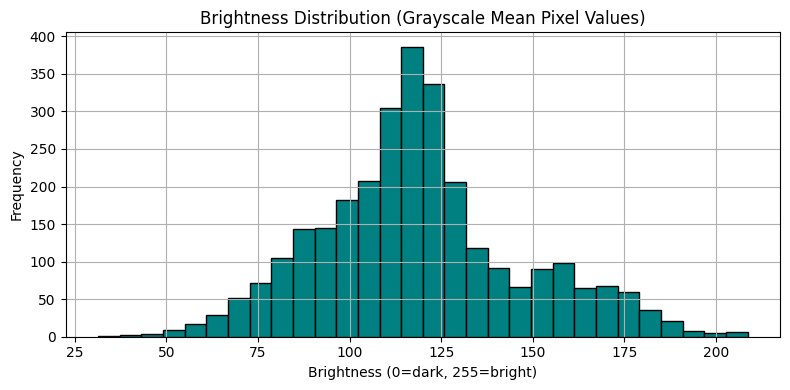

In [55]:
def compute_brightness_stats(folder_path):
    brightness_means = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(class_path, img_file)
                try:
                    img = Image.open(img_path).convert('L')
                    brightness = np.array(img).mean()
                    brightness_means.append(brightness)
                except Exception as e:
                    print(f"could not read {img_path}: {e}")

    brightness_means = np.array(brightness_means)
    mean_brightness = np.mean(brightness_means)
    std_brightness = np.std(brightness_means)

    return brightness_means, mean_brightness, std_brightness

brightness_vals, mean_brightness, std_brightness = compute_brightness_stats("split_data/train")

print(f"Mean Brightness: {mean_brightness:.2f}")
print(f"Std Dev of Brightness: {std_brightness:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(brightness_vals, bins=30, color='teal', edgecolor='black')
plt.title("Brightness Distribution (Grayscale Mean Pixel Values)")
plt.xlabel("Brightness (0=dark, 255=bright)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

The brightness distribution histogram confirms that the dataset is generally well-lit, with a Mean Brightness of 118.83. Most pixel values cluster around the 100–140 range, indicating a balanced exposure across the images. The Standard Deviation of 27.78 shows a moderate spread, where some images fall into the under-exposed (darker) or over-exposed (brighter) categories. To handle these lighting variations, rescaling (1./255) is applied during pre-processing to ensure numerical stability for the model.

### **Random Rotation Check**

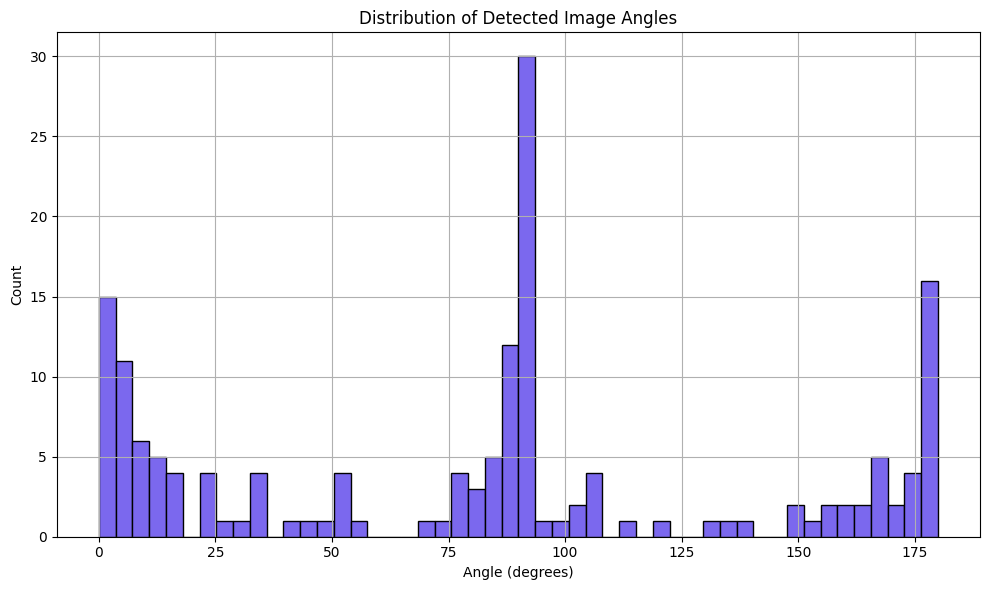

In [56]:
def calculate_orientation(image_array):
    if not isinstance(image_array, np.ndarray):
        image_array = np.array(image_array)

    grayscale = image_array if image_array.ndim == 2 else cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)

    _, binary = cv2.threshold(grayscale, 50, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    largest_contour = max(contours, key=cv2.contourArea)
    if len(largest_contour) < 5:
        return None

    _, _, angle = cv2.fitEllipse(largest_contour)
    return angle

angles = []
image_root = pathlib.Path("split_data/train")

for label in classNames:
    image_folder = image_root / label
    image_files = list(image_folder.glob("*"))

    for file_path in image_files[:50]:
        try:
            with Image.open(file_path) as im:
                image_data = np.array(im)
                orientation_angle = calculate_orientation(image_data)
                if orientation_angle is not None:
                    angles.append(orientation_angle)
        except Exception as e:
            print(f"skipped {file_path.name}: {e}")

plt.figure(figsize=(10, 6))
plt.hist(angles, bins=50, color='mediumslateblue', edgecolor='black')
plt.title("Distribution of Detected Image Angles")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the Distribution of Detected Image Angles plot, we can observe that a significant portion of our data clusters around 90 degrees, with additional peaks near 0 and 180 degrees. This indicates that while many corn leaf samples are oriented horizontally, there is still a wide variety of vertical and diagonal orientations present in the dataset.

To ensure the model can generalize well across different leaf positions and capture features regardless of how the photo was taken, I will apply random rotation during the augmentation process. This will help the model remain invariant to the orientation of the disease lesions on the leaves.

### **Image Blockage or Shifts**

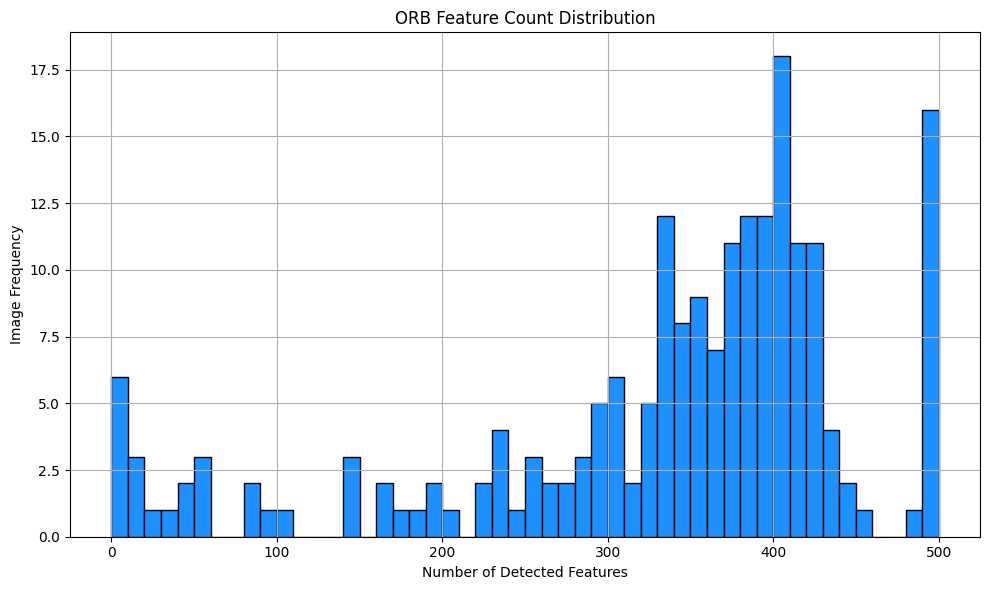

In [57]:
def blockageCheck(pil_image):
    gray_image = np.array(pil_image.convert("L"))
    detector = cv2.ORB_create()
    keypoints, _ = detector.detectAndCompute(gray_image, None)
    return len(keypoints)

# List to store feature counts
feature_counts = []

image_base = pathlib.Path("split_data/train")

for class_dir in classNames:
    folder = image_base / class_dir

    if not folder.is_dir():
        continue

    image_files = list(folder.iterdir())[:50]
    for image_file in image_files:
        if image_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            try:
                with Image.open(image_file) as img:
                    count = blockageCheck(img)
                    feature_counts.append(count)
            except Exception as e:
                print(f"error processing {image_file.name}: {e}")

plt.figure(figsize=(10, 6))
plt.hist(feature_counts, bins=50, color='dodgerblue', edgecolor='black')
plt.title('ORB Feature Count Distribution')
plt.xlabel('Number of Detected Features')
plt.ylabel('Image Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the ORB Feature Count Distribution histogram, we can observe that a majority of the images contain a high number of detected features, with a significant peak between 350 and 500 features. This indicates that most of the dataset is rich in detail, sharp, and unobstructed, which is ideal for the model to learn complex patterns on the corn leaves.

While there are a small number of images with low feature counts (near the 0-100 range) that might be blurry or plain, they represent a minority. Overall, the dataset provides sufficient visual information, and any minor inconsistencies in image clarity will be further addressed through data augmentation to ensure model robustness.

## **Preprocessing**

### **Data Splitting**

In [36]:
baseSplitDir = 'split_data'
if os.path.exists(baseSplitDir):
    shutil.rmtree(baseSplitDir)

os.makedirs(baseSplitDir)

def splitData(sourcePath, targetPath):
    categories = sorted([f.name for f in sourcePath.iterdir() if f.is_dir()])

    for cat in categories:
        files = list((sourcePath / cat).glob('*'))
        trainFiles, tempFiles = train_test_split(files, test_size=0.3, random_state=SEED_VALUE)
        valFiles, testFiles = train_test_split(tempFiles, test_size=0.5, random_state=SEED_VALUE)

        for folder in ['train', 'val', 'test']:
            os.makedirs(os.path.join(targetPath, folder, cat), exist_ok=True)

        for f in trainFiles: shutil.copy(f, os.path.join(targetPath, 'train', cat, f.name))
        for f in valFiles: shutil.copy(f, os.path.join(targetPath, 'val', cat, f.name))
        for f in testFiles: shutil.copy(f, os.path.join(targetPath, 'test', cat, f.name))

splitData(dataPath, baseSplitDir)

### **Data Augmentation**

In [62]:
trainAugments = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10
)

valAugments = ImageDataGenerator(rescale=1./255)
testAugments = ImageDataGenerator(rescale=1./255)

trainDir = "split_data/train"
valDir = "split_data/val"
testDir = "split_data/test"

trainData = trainAugments.flow_from_directory(
    trainDir,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=True,
    seed=SEED_VALUE
)

validData = valAugments.flow_from_directory(
    valDir,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=True,
    seed=SEED_VALUE
)

testData = testAugments.flow_from_directory(
    testDir,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False,
    seed=801
)

Found 2930 images belonging to 4 classes.
Found 628 images belonging to 4 classes.
Found 630 images belonging to 4 classes.


### **Baseline Model**

Our baseline model will be a recreated AlexNet model built on a sequential model

In [38]:
def buildAlexNet(numClasses):
    model = models.Sequential([
        # layer 1
        layers.Conv2D(96, kernel_size=(11, 11), strides=4, padding='valid', activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # layer 2
        layers.Conv2D(256, kernel_size=(5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # layer 3
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        # layer 4
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        # layer 5
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # flatten ke fully connected layers
        layers.Flatten(),
        # dense layer 1
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        # dense layer 2
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        # output layer
        layers.Dense(numClasses, activation='softmax')
    ])

    return model

numClasses = 4
baselineModel = buildAlexNet(numClasses)

baselineModel.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baselineModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,763,396 (178.39 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

For the baseline model, I implemented the AlexNet architecture manually using a Sequential approach. The model consists of 5 convolutional layers followed by 3 dense layers. To ensure stable convergence, I used the Adam optimizer with a low learning rate of 0.0001. This small learning rate is crucial to prevent the model from overshooting the optimal weights, especially given the large number of parameters (approx. 46 million).

Additionally, I integrated Dropout (0.5) in the fully connected layers to act as a regularization technique. Since AlexNet is a deep and heavy model, it is highly prone to overfitting. Dropout helps mitigate this by randomly deactivating neurons during training, forcing the model to learn more robust features. I decided to train for 10 epochs to achieve a balance between sufficient learning and preventing the model from becoming overfitted or underfitted on the corn leaf dataset.

In [39]:
numEpochs = 10

historyBaseline = baselineModel.fit(
    trainGen,
    epochs=numEpochs,
    validation_data=valGen,
    verbose=1
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.6215 - loss: 0.8594 - val_accuracy: 0.8360 - val_loss: 0.4478
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.7747 - loss: 0.5440 - val_accuracy: 0.8503 - val_loss: 0.4011
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 353s 4s/step - accuracy: 0.8246 - loss: 0.4251 - val_accuracy: 0.8678 - val_loss: 0.3362
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.8317 - loss: 0.3952 - val_accuracy: 0.8774 - val_loss: 0.3081
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.8471 - loss: 0.3578 - val_accuracy: 0.8774 - val_loss: 0.2931
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 378s 4s/step - accuracy: 0.8638 - loss: 0.3359 - val_accuracy: 0.8869 - val_loss: 0.2686
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.8785 - loss: 0.3181 - val_accuracy: 0.8981 - val_loss: 0.2862
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.8795 - loss: 0.3065 - val_accuracy: 0.8965 - v

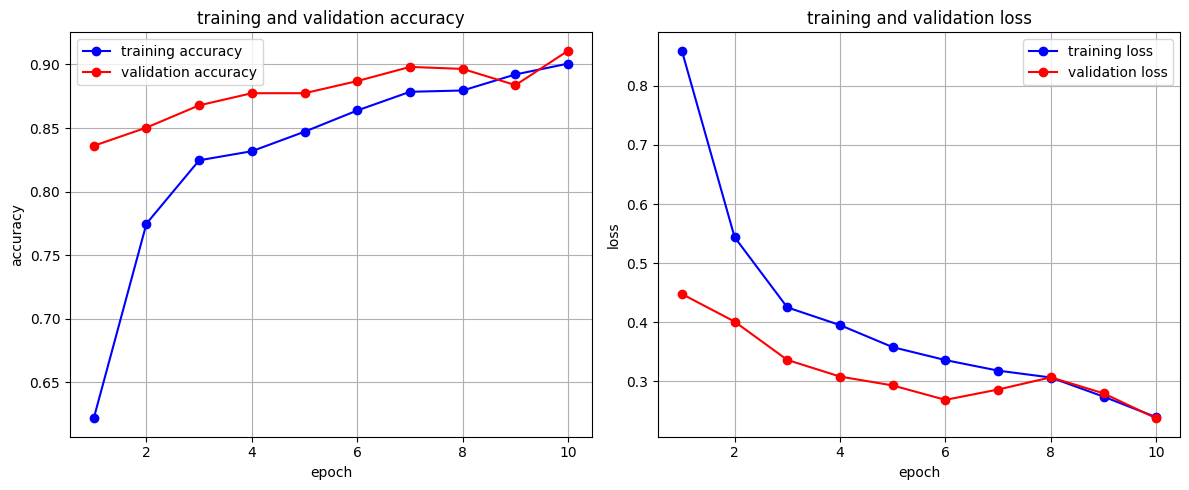

In [59]:
acc = historyBaseline.history['accuracy']
val_acc = historyBaseline.history['val_accuracy']
loss = historyBaseline.history['loss']
val_loss = historyBaseline.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='training accuracy')
plt.plot(epochs_range, val_acc, 'ro-', label='validation accuracy')
plt.title('training and validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

# plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo-', label='training loss')
plt.plot(epochs_range, val_loss, 'ro-', label='validation loss')
plt.title('training and validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [63]:
baselinePred = baselineModel.predict(testData)

baselineClassificationReport = classification_report(
    testData.classes,
    baselinePred.argmax(axis=1),
    target_names=classNames
)

print("Baseline AlexNet Classification Report")
print(baselineClassificationReport)

40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step
Baseline AlexNet Classification Report
                precision    recall  f1-score   support

        Blight       0.85      0.78      0.81       172
   Common_Rust       0.96      0.94      0.95       196
Gray_Leaf_Spot       0.68      0.80      0.74        87
       Healthy       0.99      0.99      0.99       175

      accuracy                           0.89       630
     macro avg       0.87      0.88      0.87       630
  weighted avg       0.90      0.89      0.89       630



### **Baseline Model / AlexNet Evaluation**

* Most of the classes performed exceptionally well with F1-scores above 0.80, especially the 'Healthy' class which reached near-perfection (0.99). However, the model struggled slightly with the 'Gray_Leaf_Spot' class (F1-score: 0.74), indicating that the model still has some difficulty differentiating fine-grained patterns between certain disease lesions.
* The model architecture follows the classic AlexNet structure with over 46 million parameters. While it achieved a solid 89% accuracy, the lower precision in 'Gray_Leaf_Spot' (0.68) suggests that the model is prone to false positives in that category, likely due to AlexNet being a dated architecture that lacks the advanced feature extraction capabilities of more modern networks.
* Overall, the model scored 0.89 in accuracy, which is significantly better than random guessing (1/4 ~ 25%). While this is a strong baseline performance for a manual architecture without transfer learning, the discrepancy in the 'Gray_Leaf_Spot' performance indicates there is still room for improvement through more modern architectures or fine-tuning.

## **Modified Model**

For the modified model, we shifted from a manual AlexNet architecture to Transfer Learning using MobileNetV2. This decision is based on several key advantages:

* Efficiency: MobileNetV2 is designed for mobile and resource-constrained environments, making it much faster and lighter than AlexNet.
* Pre-trained Weights: By using weights from ImageNet, the model already understands basic features like edges, textures, and shapes, which helps significantly with small custom datasets.
* Better Generalization: MobileNetV2 typically generalizes better on fine-grained patterns, which is essential for distinguishing between corn leaf diseases like Gray Leaf Spot and Blight.

In [64]:
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

modifiedModel = models.Model(inputs, outputs)

modifiedModel.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modifiedModel.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [65]:
modBaseHist = modifiedModel.fit(
    trainData,
    validation_data=validData,
    epochs=10,
    steps_per_epoch=len(trainData),
    validation_steps=len(validData)
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 182s 951ms/step - accuracy: 0.7130 - loss: 0.7338 - val_accuracy: 0.8838 - val_loss: 0.3313
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 167s 763ms/step - accuracy: 0.8355 - loss: 0.4121 - val_accuracy: 0.8885 - val_loss: 0.2752
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 131s 702ms/step - accuracy: 0.8652 - loss: 0.3395 - val_accuracy: 0.8981 - val_loss: 0.2542
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 134s 731ms/step - accuracy: 0.8870 - loss: 0.2988 - val_accuracy: 0.9092 - val_loss: 0.2402
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 139s 712ms/step - accuracy: 0.8887 - loss: 0.2823 - val_accuracy: 0.9108 - val_loss: 0.2263
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 128s 698ms/step - accuracy: 0.8918 - loss: 0.2626 - val_accuracy: 0.9029 - val_loss: 0.2321
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 133s 720ms/step - accuracy: 0.8986 - loss: 0.2539 - val_accuracy: 0.9076 - val_loss: 0.2224
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 156s 848ms/step - accuracy: 0.9034 -

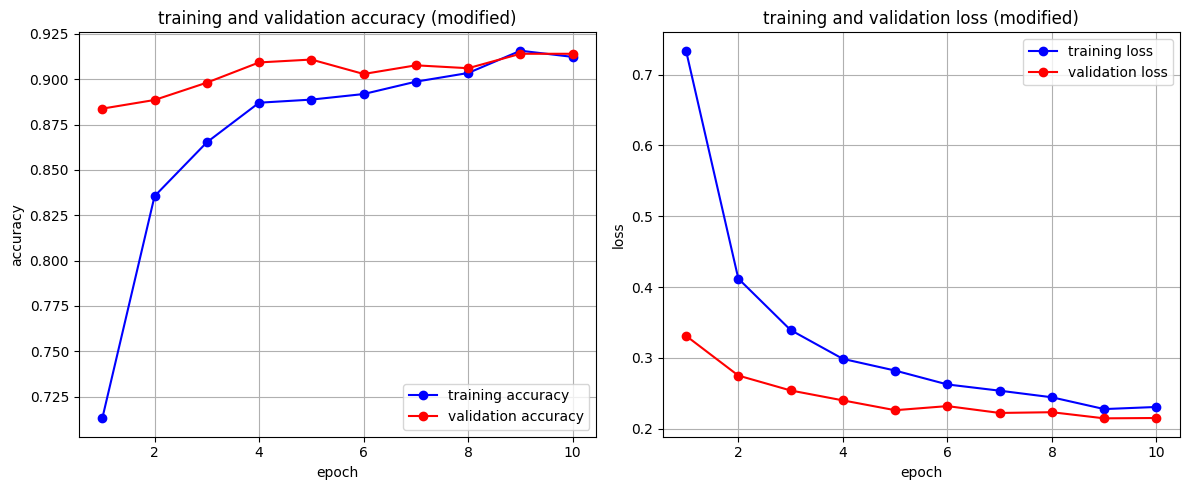

In [66]:
# extract accuracy and loss from history
modBaseacc = modBaseHist.history['accuracy']
modBaseval_acc = modBaseHist.history['val_accuracy']
modBaseloss = modBaseHist.history['loss']
modBaseval_loss = modBaseHist.history['val_loss']
epochs_range = range(1, len(modBaseacc) + 1)

# plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, modBaseacc, 'bo-', label='training accuracy')
plt.plot(epochs_range, modBaseval_acc, 'ro-', label='validation accuracy')
plt.title('training and validation accuracy (modified)')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

# plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, modBaseloss, 'bo-', label='training loss')
plt.plot(epochs_range, modBaseval_loss, 'ro-', label='validation loss')
plt.title('training and validation loss (modified)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [67]:
modBasePred = modifiedModel.predict(testData)
modBaseClasificationReport = classification_report(
    testData.classes,
    modBasePred.argmax(axis=1),
    target_names=classNames
)

print("Modified MobileNetV2 Classification Report")
print(modBaseClasificationReport)

40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 454ms/step
Modified MobileNetV2 Classification Report
                precision    recall  f1-score   support

        Blight       0.91      0.85      0.88       172
   Common_Rust       0.95      0.96      0.96       196
Gray_Leaf_Spot       0.78      0.86      0.82        87
       Healthy       0.99      0.99      0.99       175

      accuracy                           0.93       630
     macro avg       0.91      0.92      0.91       630
  weighted avg       0.93      0.93      0.93       630



### **Modified Model / MobileNet Evaluation**

* On the F1-Score metric, we can see a significant improvement in the categories that were previously weak in the AlexNet model. Specifically, the 'Gray_Leaf_Spot' class improved from 0.74 to 0.82, and 'Blight' rose from 0.81 to 0.88. This is a clear sign of MobileNetV2's superior ability to preserve spatial locality and detect fine-grained patterns in corn leaf diseases more effectively than the dated AlexNet architecture.
* Based on the training vs. validation charts, the model shows signs of being slightly underfitted during the initial epochs, as the validation accuracy and loss consistently performed better than the training metrics. This gap is likely due to the frozen layers of the pre-trained MobileNetV2 and the limited number of epochs (10). However, the curves began to converge toward the end, and this behavior will be further addressed and optimized during the fine-tuning stage.
* The model's overall accuracy has increased to 0.93 (93%) compared to AlexNet's 0.89. While an accuracy above 90% is excellent for agricultural data, there is still a small margin for error in distinguishing between similar lesions. With an accuracy nearly 4x better than random guessing (1/4 ~ 25%), the model has proven its efficiency. After the upcoming fine-tuning steps, the performance should stabilize even further across all classes.

### **Modified Model Fine Tuning**

In [68]:
base_model.trainable = True

fineTuneAt = 100
for layer in base_model.layers[:fineTuneAt]:
    layer.trainable = False

modifiedModel.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modFT = modifiedModel.fit(
    trainData,
    validation_data=validData,
    epochs=15,
    steps_per_epoch=len(trainData),
    validation_steps=len(validData)
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 189s 957ms/step - accuracy: 0.7812 - loss: 0.5252 - val_accuracy: 0.9076 - val_loss: 0.2324
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 195s 916ms/step - accuracy: 0.8795 - loss: 0.3301 - val_accuracy: 0.8965 - val_loss: 0.2336
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 205s 936ms/step - accuracy: 0.8915 - loss: 0.2716 - val_accuracy: 0.9061 - val_loss: 0.2256
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 168s 914ms/step - accuracy: 0.9031 - loss: 0.2605 - val_accuracy: 0.9108 - val_loss: 0.2136
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 183s 993ms/step - accuracy: 0.9099 - loss: 0.2378 - val_accuracy: 0.9140 - val_loss: 0.2009
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 187s 914ms/step - accuracy: 0.9109 - loss: 0.2366 - val_accuracy: 0.9172 - val_loss: 0.1902
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 170s 923ms/step - accuracy: 0.9137 - loss: 0.2150 - val_accuracy: 0.9236 - val_loss: 0.1866
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 167s 909ms/step - accuracy: 0.9171 -

I increased the training to 15 epochs while lowering the learning rate to 0.00001 to allow the model more time to adapt to the specialized corn leaf features without risking overfitting or destabilizing the pre-trained weights.

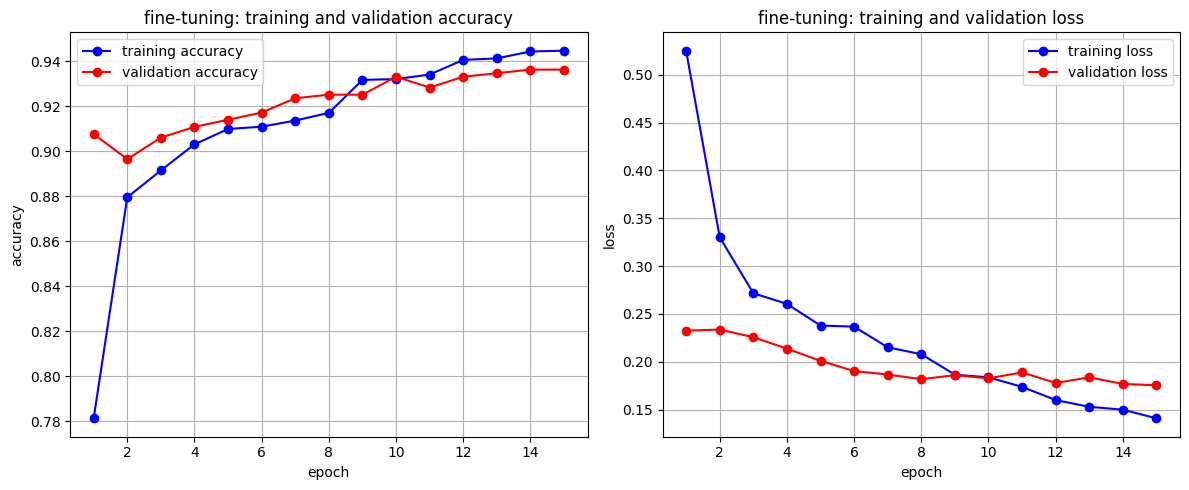

In [69]:
# extract accuracy and loss from fine-tuning history
modFTacc = modFT.history['accuracy']
modFTval_acc = modFT.history['val_accuracy']
modFTloss = modFT.history['loss']
modFTval_loss = modFT.history['val_loss']
epochs_range = range(1, len(modFTacc) + 1)

# plot for accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, modFTacc, 'bo-', label='training accuracy')
plt.plot(epochs_range, modFTval_acc, 'ro-', label='validation accuracy')
plt.title('fine-tuning: training and validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

# plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, modFTloss, 'bo-', label='training loss')
plt.plot(epochs_range, modFTval_loss, 'ro-', label='validation loss')
plt.title('fine-tuning: training and validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
modFTPred = modifiedModel.predict(testData)

modFTClassificationReport = classification_report(
    testData.classes,
    modFTPred.argmax(axis=1),
    target_names=classNames
)

print("Modified MobileNetV2 Classification Report Fine Tuned")
print(modFTClassificationReport)

40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 439ms/step
Modified MobileNetV2 Classification Report Fine Tuned
                precision    recall  f1-score   support

        Blight       0.96      0.89      0.92       172
   Common_Rust       0.98      0.99      0.99       196
Gray_Leaf_Spot       0.81      0.91      0.86        87
       Healthy       0.99      1.00      1.00       175

      accuracy                           0.95       630
     macro avg       0.94      0.95      0.94       630
  weighted avg       0.96      0.95      0.95       630



### **Fine Tuned Model Evaluation**

* The model has improved significantly, as seen in the F1-scores across all categories. The 'Gray_Leaf_Spot' class, which was our weakest point, has now reached a strong score of 0.86. Additionally, the 'Blight' class improved to 0.92, showing that the model is now much better at distinguishing subtle differences between disease lesions.
* Comparing our validation vs. training accuracy and loss plots to the previous stages, we can see a clear improvement. The lines have started to converge much more closely. This indicates that our Fine-Tuned MobileNet model is neither underfitted nor overfitted, achieving a very healthy balance in generalization.
* Overall, our model scored 0.95 in accuracy. This is a significant increase compared to our AlexNet baseline (0.89) and the initial MobileNet (0.93). This steady progression proves that the combination of transfer learning and precise fine-tuning allowed the model to reach its peak performance in detecting corn leaf diseases.

# **Model Evaluation**

## **Quick Model Recap**

### **AlexNet**
- Slowest training time with the lowest overall accuracy (0.89).
- Struggled significantly with fine-grained patterns, especially in the 'Gray_Leaf_Spot' class.
- Outdated architecture without Transfer Learning, lacks the depth needed for complex medical/agricultural data.

### **Base MobileNet**
- Faster and more efficient with a significant accuracy jump to 0.93.
- Much better at identifying ambiguous lesions, though still showing signs of underfitting due to frozen layers.
- Promising results but required further optimization to reach its full potential.

### **FineTuned MobileNet**
- The top performer with the highest accuracy (0.95) and best F1-scores across all categories.
- Excellent generalization; successfully "learned" specific features of corn diseases by unfreezing deep layers.
- The most reliable model for real-world deployment, showing near-perfect detection for 'Healthy' and 'Common_Rust' cases.

## **Overall Evaluation**

- Our final model demonstrates that with strategic tuning and Transfer Learning, even a small dataset can yield significant improvements. It also proves that heavier, classic architectures like AlexNet don't always perform better than modern, efficient models like MobileNetV2, highlighting the importance of optimizing technology for better efficiency.
- While the metrics for our final model are excellent (95% accuracy), there is still room for improvement. In real-world agricultural scenarios, high accuracy in 'Healthy' or 'Severe Rust' cases is expected, but the real challenge lies in the ambiguous 'Gray_Leaf_Spot' and 'Blight' classes. Future iterations should focus on these subtle patterns to ensure early and accurate detection.
- The promising results achieved with this relatively simple setup and limited data show great potential. With further fine-tuning, more diverse data collection, and advanced preprocessing, I am confident the model's reliability can be enhanced further for practical field deployment.